In [32]:
import pandas as pd

In [33]:
df=pd.read_parquet("../Dataset/text_emotion.parquet")
df.head()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [34]:
def emotion_map(label):
    if label == 0:
        return "sadness"
    elif label == 1:
        return "joy"
    elif label == 2:
        return "love"
    elif label == 3:
        return "anger"
    elif label == 4:
        return "fear"
    elif label == 5:
        return "surprise"
    

df["emotion"]=df["label"].apply(emotion_map)

In [35]:
df.head()

,text,label,emotion
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love


In [36]:
df.describe()

,label
count,416809.000000
mean,1.554271
std,1.490453
min,0.000000
25%,0.000000
50%,1.000000
75%,3.000000
max,5.000000


In [37]:
df["label"].value_counts()

label
1    141067
0    121187
3     57317
4     47712
2     34554
5     14972
Name: count, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

df,_=train_test_split(df,stratify=df["emotion"],train_size=.10)

<Axes: title={'center': 'Emotion Distribution'}, xlabel='emotion'>

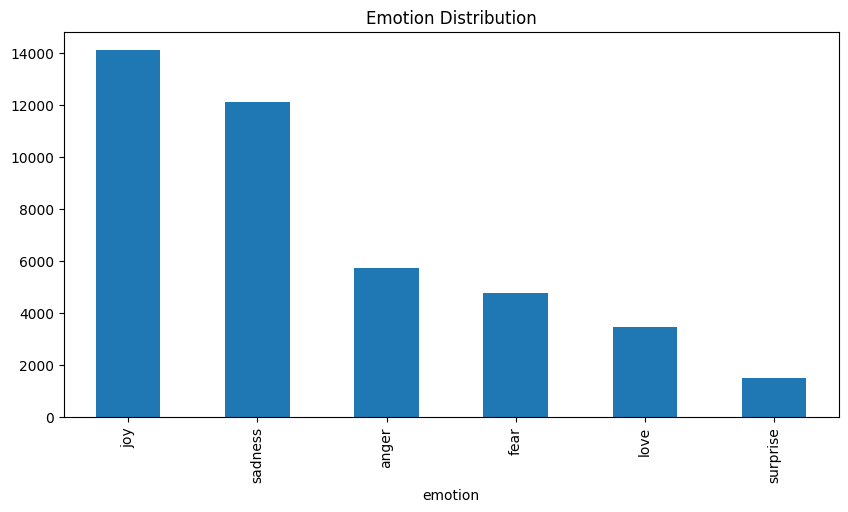

In [39]:
df["emotion"].value_counts().plot(kind="bar", figsize=(10, 5), title="Emotion Distribution")

### What is AutoTokenizer?

`AutoTokenizer` is part of the `transformers` library by Hugging Face, which provides an easy interface for working with pretrained models, specifically for Natural Language Processing (NLP) tasks.

It is used to **tokenize** text in a way that is compatible with a pretrained model, which is a critical step for converting human-readable text into the form that a model can process. Tokenization is the process of breaking down text into smaller units, often called **tokens** (e.g., words or subwords). These tokens are then mapped to corresponding numbers (IDs), which can be fed into the model.

The term "Auto" refers to the fact that `AutoTokenizer` is an **automated version**, meaning it can automatically choose the right tokenizer for the model you are using, based on the model's configuration.

### What Does AutoTokenizer Do?

1. **Text Preprocessing**: The primary job of `AutoTokenizer` is to preprocess and tokenize the input text. This is crucial because most NLP models cannot work with raw text directly. The text needs to be tokenized and converted into numerical representations.

2. **Model Compatibility**: It ensures that the tokenization process is compatible with the specific pretrained model you intend to use (e.g., BERT, GPT, T5, etc.). This is why `AutoTokenizer` automatically detects and loads the correct tokenizer associated with the model.

3. **Subword Tokenization**: Many modern NLP models, such as BERT or GPT, use a technique called **subword tokenization** (e.g., using WordPiece or Byte-Pair Encoding). This helps handle out-of-vocabulary (OOV) words by splitting them into smaller, meaningful units.

4. **Padding & Truncation**: The `AutoTokenizer` also ensures that sequences are either **padded** to a fixed length or **truncated** if they exceed the maximum sequence length the model can handle.

5. **Token IDs & Attention Masks**: After tokenizing the text, the `AutoTokenizer` will provide two important outputs:

   * **Token IDs**: These are the numerical representations of each token in the model's vocabulary.
   * **Attention Masks**: This tells the model which tokens are actual words and which are padding. It helps the model ignore padding tokens during computation.

### How Does It Work?

1. **Loading the Tokenizer**: To use `AutoTokenizer`, you first load it for a specific pretrained model using its name. For example, if you want to use BERT, you load the tokenizer for BERT.

   ```python
   from transformers import AutoTokenizer

   tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
   ```

2. **Tokenizing the Input**: Once the tokenizer is loaded, you can use it to tokenize text. For example:

   ```python
   inputs = tokenizer("Hello, how are you?", padding=True, truncation=True)
   ```

   This will tokenize the text `"Hello, how are you?"`, pad it if necessary, and truncate it if it's too long.

### Key Output of AutoTokenizer

When you call `AutoTokenizer` to tokenize text, it typically returns a dictionary containing several pieces of information:

1. **Input IDs (`input_ids`)**: These are the numerical representations of the tokens in the text. For example, if the tokenizer is based on BERT, these are the indices from the BERT vocabulary.

   Example output for `input_ids` (BERT-based tokenizer):

   ```python
   input_ids = [101, 7592, 117, 1139, 2025, 102]
   ```

   Here, `101` represents the special `[CLS]` token (for classification tasks), and `102` represents the special `[SEP]` token (used to separate sentences).

2. **Attention Masks (`attention_mask`)**: This is a list where each value indicates whether a token should be attended to (`1`) or ignored (`0`, e.g., for padding tokens). The attention mask tells the model to ignore the padding tokens when processing the text.

   Example output for `attention_mask`:

   ```python
   attention_mask = [1, 1, 1, 1, 1, 1]
   ```

   This tells the model that all tokens should be attended to (because there’s no padding).

3. **Tokenized Text (`tokens`)**: This is the list of tokens obtained after tokenization, showing how the input text is split into smaller units (subwords or words).

   Example:

   ```python
   tokens = ['[CLS]', 'hello', ',', 'how', 'are', 'you', '?', '[SEP]']
   ```

### Example Walkthrough

Let's see a detailed example using the `AutoTokenizer` with the BERT model:

```python
from transformers import AutoTokenizer

# Load the BERT tokenizer
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

# Tokenize a sample text
input_text = "Hello, how are you?"
tokenized_output = tokenizer(input_text, padding=True, truncation=True)

print(tokenized_output)
```

**Output**:

```python
{
  'input_ids': [101, 7592, 117, 1139, 2025, 102],
  'attention_mask': [1, 1, 1, 1, 1, 1],
  'token_type_ids': [0, 0, 0, 0, 0, 0],
  'tokens': ['[CLS]', 'hello', ',', 'how', 'are', 'you', '?', '[SEP]']
}
```

* **`input_ids`**: The tokenized input text mapped to numerical values.
* **`attention_mask`**: Indicates that all tokens should be attended to.
* **`token_type_ids`**: Used for sentence pair tasks (not relevant for a single sentence input in this case).
* **`tokens`**: The tokens as they appeared after tokenization, including special tokens like `[CLS]` and `[SEP]`.

### Key Points to Remember
* **truncation=True**: ensures that if the tokenized text exceeds the specified max_length, it will be truncated.
* **Compatibility**: `AutoTokenizer` automatically loads the correct tokenizer for the pretrained model.
* **Subword Tokenization**: Modern tokenizers handle OOV words by breaking them into subwords.
* **Padding and Truncation**: It can automatically pad and truncate sequences to a fixed length.
* **Output**: The key outputs are token IDs, attention masks, and sometimes token type IDs and tokens themselves.

### Conclusion

`AutoTokenizer` makes it easier to handle text preprocessing for NLP tasks, as it ensures that your input is appropriately tokenized and formatted for the model you are working with. Whether you're fine-tuning a model or using a pretrained one, `AutoTokenizer` simplifies the text tokenization process and ensures compatibility with a range of models.


In [40]:
from transformers import AutoTokenizer

model_checkpoint ="bert-base-uncased"

tokenizer=AutoTokenizer.from_pretrained(model_checkpoint)

C:\Users\Lenovo\AppData\Roaming\Python\Python311\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [41]:
demo="i am so happy today. Where are others"
inputs=tokenizer(demo,padding=True, truncation=True)
print(inputs)

{'input_ids': [101, 1045, 2572, 2061, 3407, 2651, 1012, 2073, 2024, 2500, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [42]:
len(tokenizer.vocab)

30522

In [43]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'])
print("Tokens:", tokens)

Tokens: ['[CLS]', 'i', 'am', 'so', 'happy', 'today', '.', 'where', 'are', 'others', '[SEP]']


In [44]:
def word_len(text):
    return len(text.split())

df["words"]=df["text"].apply(word_len)

In [45]:
df.head()

,text,label,emotion,words
117153,i respond to rejection with very hurt feelings...,0,sadness,18
318876,i was definitely feeling optimistic when my vo...,1,joy,16
344267,i couldnt help wonder what it would feel like ...,1,joy,23
84824,i looked down at my feet feeling so ashamed,0,sadness,9
327777,i am reminded that i have been close friends w...,1,joy,49


In [46]:
from sklearn.model_selection import train_test_split

train,test=train_test_split(df,stratify=df["emotion"],test_size=.3)

test,val=train_test_split(test,stratify=test["emotion"],test_size=.25)

train.shape, test.shape, val.shape

((29176, 4), (9378, 4), (3126, 4))

In [47]:
from datasets import Dataset, DatasetDict

dataset=DatasetDict(
    {
        "train":Dataset.from_pandas(train),
        "test":Dataset.from_pandas(test), 
        "val":Dataset.from_pandas(val)
    }
)
dataset


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'emotion', 'words', '__index_level_0__'],
        num_rows: 29176
    })
    test: Dataset({
        features: ['text', 'label', 'emotion', 'words', '__index_level_0__'],
        num_rows: 9378
    })
    val: Dataset({
        features: ['text', 'label', 'emotion', 'words', '__index_level_0__'],
        num_rows: 3126
    })
})

The extra column you're seeing (__index_level_0__) in the DatasetDict output might be a result of how the data was read into the Dataset from your pandas DataFrame. This often occurs when the index column of a DataFrame is inadvertently included as a regular column during the conversion to a Dataset.

In [48]:
dataset=DatasetDict(
    {
        "train":Dataset.from_pandas(train,preserve_index=False),
        "test":Dataset.from_pandas(test,preserve_index=False), 
        "val":Dataset.from_pandas(val,preserve_index=False)
    }
)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'emotion', 'words'],
        num_rows: 29176
    })
    test: Dataset({
        features: ['text', 'label', 'emotion', 'words'],
        num_rows: 9378
    })
    val: Dataset({
        features: ['text', 'label', 'emotion', 'words'],
        num_rows: 3126
    })
})

In [49]:
dataset["train"][0]

{'text': 'i feel unhappy unless i have some type of sugar in my system haha ive got such a sweet tooth',
 'label': 0,
 'emotion': 'sadness',
 'words': 20}

In [50]:
def tokenize_function(data):
    converted=tokenizer(data["text"],padding=True,truncation=True) # truncation=True ensures that if the tokenized text exceeds the specified max_length, it will be truncated.
    return converted

tokenize_function(dataset["train"][0])


{'input_ids': [101, 1045, 2514, 12511, 4983, 1045, 2031, 2070, 2828, 1997, 5699, 1999, 2026, 2291, 5292, 3270, 4921, 2063, 2288, 2107, 1037, 4086, 11868, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

1. **`input_ids`**:

* **Meaning**: These are the token IDs (numerical representations) corresponding to the tokens in the input text. The tokenizer converts each word or subword into an integer based on its position in the model's vocabulary.
* **Example**: `[101, 10047, 3110, 3565, 7782, 1045, 2453, 3657, 2588, 2014, 4175, 8189, 5897, 102]`

  * These numbers represent the tokens in your input text after tokenization. Special tokens like `[101]` and `[102]` are used to denote the beginning (`[CLS]`) and end (`[SEP]`) of the sequence, respectively. The rest are the token IDs of the words or subwords.

2. **`token_type_ids`**:

* **Meaning**: This is used for distinguishing different segments of input text (e.g., sentence A vs. sentence B in tasks like question answering). In single-sentence tasks like text classification, this array will generally be filled with zeros, indicating that all tokens belong to a single segment.
* **Example**: `[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]`

  * All values are `0`, meaning there’s only one sentence or segment in the input. If you were using the tokenizer for tasks like sentence pairs (e.g., natural language inference), the second sentence would have `1` in its `token_type_ids`.

3. **`attention_mask`**:

* **Meaning**: The attention mask is used to indicate which tokens should be attended to by the model and which should be ignored (usually padding tokens). Tokens with `1` are actual tokens to be processed, while tokens with `0` are padding tokens that should be ignored.
* **Example**: `[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]`

* **`101`**: This is the **\[CLS]** token (used for classification tasks).
* **`102`**: This is the **\[SEP]** token (used to separate sequences or mark the end).


In [51]:
encoded=dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/29176 [00:00<?, ? examples/s]

Map:   0%|          | 0/9378 [00:00<?, ? examples/s]

Map:   0%|          | 0/3126 [00:00<?, ? examples/s]

The use of **`label2id`** and **`id2label`** is not exclusive to BERT; it's a common practice across many machine learning models, especially in classification tasks. These mappings are needed whenever:

1. **The model works with numeric labels**: Most models (including BERT, GPT, RoBERTa, etc.) require numeric values as labels for training and predictions. Text labels (e.g., "positive," "negative") must be converted to numbers, and the reverse must happen during inference.

2. **Multi-class or multi-label classification**: For tasks where there are multiple classes (e.g., sentiment analysis, spam detection, etc.), these mappings ensure that each class has a unique numeric representation.

### Other models:

* **CNNs**: In tasks like image classification, labels are often converted into numeric IDs (e.g., "cat" → 0, "dog" → 1).
* **RNNs/LSTMs**: In sequence classification or token classification, these models also use label mappings for converting text labels to numbers and vice versa.

So, **`label2id`** and **`id2label`** are used in **any model** that requires mapping between text labels and numeric representations for classification tasks.


In [52]:
dataset["train"][0]

{'text': 'i feel unhappy unless i have some type of sugar in my system haha ive got such a sweet tooth',
 'label': 0,
 'emotion': 'sadness',
 'words': 20}

In [53]:
label2id={x["emotion"]: x["label"] for x in dataset["train"]}
id2label={ v:k for k,v in label2id.items()} # vice versa of label2id


In [54]:
label2id, id2label

({'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'surprise': 5, 'fear': 4},
 {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 5: 'surprise', 4: 'fear'})

In [55]:
from transformers import AutoModelForSequenceClassification,AutoConfig
import torch

device =torch.device("cuda" if torch.cuda.is_available() else "cpu")

config=AutoConfig.from_pretrained(model_checkpoint, label2id=label2id, id2label=id2label) 

model=AutoModelForSequenceClassification.from_pretrained(model_checkpoint,config=config).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [56]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [57]:
model.config.architectures

['BertForMaskedLM']

In [58]:
from transformers import TrainingArguments

batch_size = 64
training_dirs = "bert-emotion-understand"

training_args = TrainingArguments(
    output_dir=training_dirs,
    # Using eval_steps for older versions instead of evaluation_strategy
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=2,
    disable_tqdm=False,
)



In [59]:
from evaluate import load
accuracy = load("accuracy")

Using the latest cached version of the module from C:\Users\Lenovo\.cache\huggingface\modules\evaluate_modules\metrics\evaluate-metric--accuracy\f887c0aab52c2d38e1f8a215681126379eca617f96c447638f751434e8e65b14 (last modified on Tue Jul  8 02:02:19 2025) since it couldn't be found locally at evaluate-metric--accuracy, or remotely on the Hugging Face Hub.


In [60]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=-1)
    return accuracy.compute(predictions=predictions, references=labels)

In [61]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded["train"],
    eval_dataset=encoded["val"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
)

In [62]:
trainer.train()

  0%|          | 0/912 [00:00<?, ?it/s]

c:\Users\Lenovo\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyboardInterrupt: 